#Regression and Classification - Supervised learning techniques


#Machine Learning:
Supervised Learning: trains models on labeled data to predict or classify new, unseen data. Supervised learning algorithms solve classification and regression problems.

Unsupervised Learning: finds patterns or groups in unlabeled data.<br><br>

#Classification
Classification models learn decision boundaries that separate one class from another. They use activation functions such as Sigmoid to map outputs between 0 and 1 as a probability.<br><br>

###Classification algorithms
-Logistic regression<br>
-Support vector machine<br>
-K-nearest neighbors<br>
-Naive Bayes<br>
-Decision tree<br>
-Random forest<br><br>

###Applications
-Email filtering<br>
-Medical diagnosis<br>
-Image recognition<br>
-Sentiment analysis<br>
-Fraud detection<br>
-Customer segmentation<br><br>



#Regression
Regression models predict a continuous outcome value using the input variables.  It identifies trends and patterns in data to make future predictions or estimate unknown values based on learned relationships.

y = f(x), where input features x are mapped to a continuous output y<br><br>


###Regression algorithms
-Linear regression<br>
-Polynomial regression<br>
-Decision tree<br>
-Random forest<br>
-Support vector <br><br>


###Applications
-Sales forecasting<br>
-Healthcare predictions<br>
-Market trend analysis<br>
-Housing demand <br>
-Stock value prediction<br>
-Energy consumption<br>






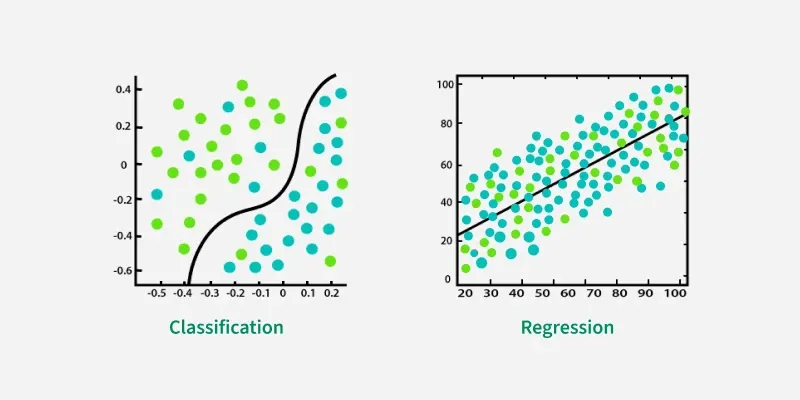

#Use of K-Nearest Neighbors Classification algorithm to predict a fruit


In [66]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

fruits = pd.read_csv("fruit_data_with_colors.txt",sep='\t')

In [67]:
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [68]:
fruits.describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.693220,0.762881
std,1.208048,55.018832,0.816938,1.361017,0.076857
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [69]:
fruits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fruit_label    59 non-null     int64  
 1   fruit_name     59 non-null     object 
 2   fruit_subtype  59 non-null     object 
 3   mass           59 non-null     int64  
 4   width          59 non-null     float64
 5   height         59 non-null     float64
 6   color_score    59 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 3.4+ KB


In [70]:
# create a mapping from fruit label value to fruit name to make results easier to interpret
lookup_fruit_name = dict(zip(fruits.fruit_label.unique(), fruits.fruit_name.unique()))
lookup_fruit_name

{np.int64(1): 'apple',
 np.int64(2): 'mandarin',
 np.int64(3): 'orange',
 np.int64(4): 'lemon'}

The file contains the mass, height, and width of a selection of oranges, lemons and apples. The heights were measured along the core of the fruit. The widths were the widest width perpendicular to the height.

/tmp/ipython-input-182/3592742359.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gnuplot')


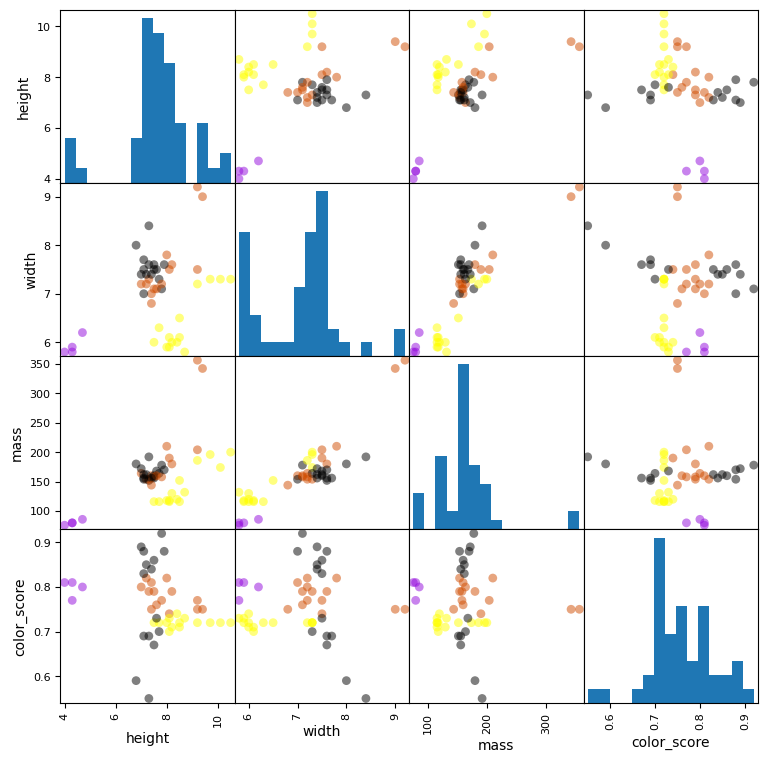

In [71]:
# plotting a scatter matrix
from matplotlib import cm

X = fruits[['height', 'width', 'mass', 'color_score']]
y = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size=0.20)

cmap = cm.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(X_train, c= y_train, marker = 'o', s=40, hist_kwds={'bins':15}, figsize=(9,9), cmap=cmap)


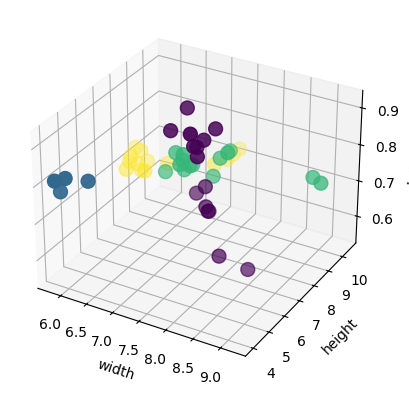

In [72]:
# plotting a 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_train['width'], X_train['height'], X_train['color_score'], c = y_train, marker = 'o', s=100)
ax.set_xlabel('width')
ax.set_ylabel('height')
ax.set_zlabel('color_score')
plt.show()

#create train test split

In [73]:
# For this example, we use the mass, width, and height features of each fruit instance
X = fruits[['mass', 'width', 'height']]
y = fruits['fruit_label']

# default is 80% / 20% train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size=0.2)

ML model steps
1. model creation
2. fitting/training
3. scoring/evaluation
4. prediction

data set contains both train and test sets. Usually test set is 30% of the whole data set. Train data is used for training model and generate algorithms and test data is output data set. test data set is randomly picked i.e. 30%


### Create classifier object

In [74]:
# scikit-learn is an open source library for predictive data analysis, built on NumPy, SciPy, and matplotlib

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 11)


### Train the classifier (fit the estimator) using the training data

In [75]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

### Estimate the accuracy of the classifier on future data, using the test data

In [76]:
knn.score(X_test, y_test)  #use score function to evaluate the accuracy

0.4166666666666667

In [77]:
predict = knn.predict(X_test)
print(predict)
print(y_test)
print(accuracy_score(y_test, predict))  # use accuracy_score to evaluate the accuracy

[3 1 3 1 1 1 1 3 1 1 4 1]
26    3
35    3
43    4
28    3
11    1
2     1
34    3
46    4
40    3
22    1
4     2
10    1
Name: fruit_label, dtype: int64
0.4166666666666667


### Scaling is used for easy prediction for models. Process of transforming all data values to one level so its easy for model to predict. salary values, age, etc.. all transformed to values between 0 to 1.

High accuracy is preferred finally for any model which could be based on combination of k value, pre processing techniques like scaling, etc..


#### Use the trained k-NN classifier model to classify new, previously unseen objects

In [78]:
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm
fruit_prediction = knn.predict([[20, 4.3, 5.5]])
print(fruit_prediction)
lookup_fruit_name[fruit_prediction[0]]

[4]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

In [79]:
# second example: a larger, elongated fruit with mass 100g, width 6.3 cm, height 8.5 cm
fruit_prediction = knn.predict([[100, 6.3, 8.5]])
lookup_fruit_name[fruit_prediction[0]]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

### How sensitive is k-NN classification accuracy to the choice of the 'k' parameter?


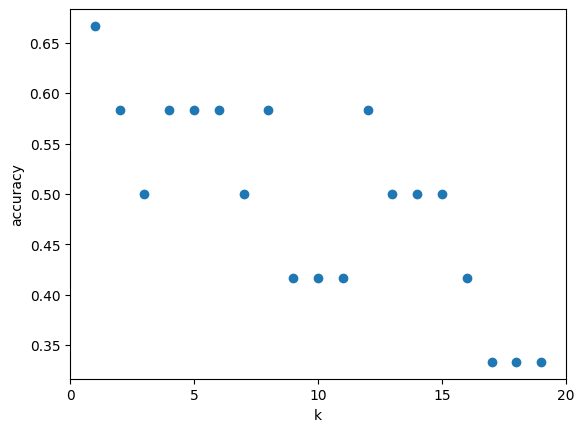

In [80]:
k_range = range(1,20)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20]);

In [81]:
X.head()

,mass,width,height
0,192,8.4,7.3
1,180,8.0,6.8
2,176,7.4,7.2
3,86,6.2,4.7
4,84,6.0,4.6


In [82]:
# use min max scaling to preprocess the data
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
X = minmax.fit_transform(X)

In [83]:
print(X[0])
print(y[15])

[0.40559441 0.68421053 0.50769231]
1


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0,test_size=0.2)

from sklearn.neighbors import KNeighborsClassifier

knn_scaled = KNeighborsClassifier(n_neighbors = 5)
knn_scaled.fit(X_train, y_train)
knn_scaled.score(X_test, y_test)  #use score function to evaluate the accuracy

0.6666666666666666

### How sensitive is k-NN classification accuracy to the train/test split proportion?

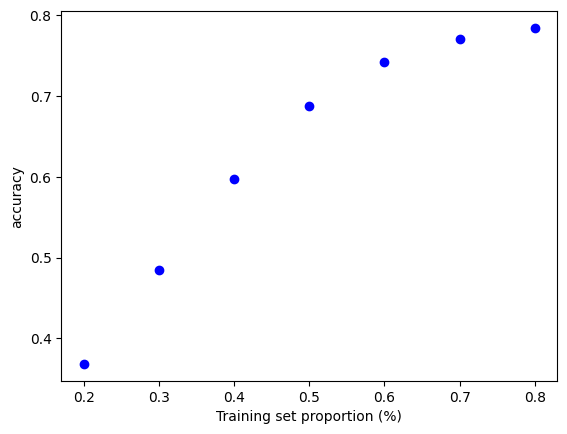

In [85]:
t = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

knn = KNeighborsClassifier(n_neighbors = 5)

plt.figure()

for s in t:

    scores = []
    for i in range(1,1000):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1-s)
        knn.fit(X_train, y_train)
        scores.append(knn.score(X_test, y_test))
    plt.plot(s, np.mean(scores), 'bo')

plt.xlabel('Training set proportion (%)')
plt.ylabel('accuracy');

In [86]:
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm
fruit_prediction = knn_scaled.predict([[0.27, 0.5, 0.47]])
lookup_fruit_name[fruit_prediction[0]]

'apple'